# Polynomial Regression
* 다항(폴리노미얼 리그레션) 회귀
* 2차 방식
* 변곡점 마다 제곱

In [11]:
import numpy as np
import pandas as pd
import seaborn as sns     

import matplotlib.pyplot as plt   
import matplotlib as mpl          
mpl.rc('font', family='Malgun Gothic ')    
plt.rcParams['axes.unicode_minus']=False

import scipy.stats as stats

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge, Lasso, ElasticNet

from sklearn.preprocessing import PolynomialFeatures        # 폴리노미얼 피처스
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [13]:
# 다항 회귀 - 농어 무게

perch_length=np.array(
    [8.4, 13.7, 15.0, 16.2, 17.4, 18.0, 18.7, 19.0, 19.6, 20.0,
     21.0, 21.0, 21.0, 21.3, 22.0, 22.0, 22.0, 22.0, 22.0, 22.5,
     22.5, 22.7, 23.0, 23.5, 24.0, 24.0, 24.6, 25.0, 25.6, 26.5,
     27.3, 27.5, 27.5, 27.5, 28.0, 28.7, 30.0, 32.8, 34.5, 35.0,
     36.5, 36.0, 37.0, 37.0, 39.0, 39.0, 39.0, 40.0, 40.0, 40.0,
     40.0, 42.0, 43.0, 43.0, 43.5, 44.0])

perch_weight=np.array(
    [5.9, 32.0, 40.0, 51.5, 70.0, 100.0, 78.0, 80.0, 85.0, 85.0,
     110.0, 115.0, 125.0, 130.0, 120.0, 120.0, 130.0, 135.0, 110.0,
     130.0, 150.0, 145.0, 150.0, 170.0, 225.0, 145.0, 188.0, 180.0,
     197.0, 218.0, 300.0, 260.0, 265.0, 250.0, 250.0, 300.0, 320.0,
     514.0, 556.0, 840.0, 685.0, 700.0, 700.0, 690.0, 900.0, 650.0,
     820.0, 850.0, 900.0, 1015.0, 820.0, 1100.0, 1000.0, 1100.0,
     1000.0, 1000.0])

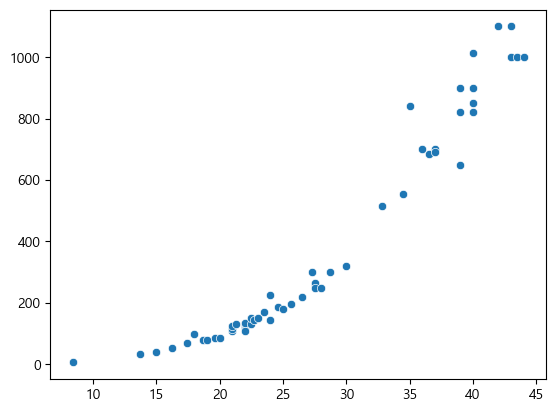

In [15]:
sns.scatterplot(x=perch_length, y=perch_weight)
plt.show()

# 곡선에 가깝다. 
# 예측 참조 : 0.939846333997604 / 0.8247503123313558

- 독립 변수의 제곱, 세제곱, 네제곱 등과 같은 고차항을 추가하여 비선형성을 모델링
- 이렇게 함으로써 모델은 더 복잡한 데이터 패턴을 캡처할 수 있게 된다.
- 사이킷런에서는 다항회귀 클래스를 제공하지 않는다.

In [18]:
# a=np.array([1, 2, 3])  
# b=np.array([4, 5, 6])  
# result=np.column_stack((a, b))
# result

In [20]:
X_train, X_test, Y_train, Y_test=train_test_split(perch_length, perch_weight, random_state=42)

# 2차 방정식 : Y=WX^2 + WX + B
X_train_poly=np.column_stack((X_train ** 2, X_train))      # 1차원 배열(벡터)을 열(column) 기준으로 결합 
X_test_poly=np.column_stack((X_test ** 2, X_test))

print(X_train_poly.shape, X_test_poly.shape)
print(X_train_poly[:5])

# 3차 방정식 : Y=WX^3 + WX^2 + WX + B
# X_train_poly=np.column_stack((X_train ** 3, X_train ** 2, X_train))

(42, 2) (14, 2)
[[ 384.16   19.6 ]
 [ 484.     22.  ]
 [ 349.69   18.7 ]
 [ 302.76   17.4 ]
 [1296.     36.  ]]


In [22]:
lr=LinearRegression()
lr.fit(X_train_poly, Y_train)

print("학습:", lr.score(X_train_poly, Y_train))
print("일반화:", lr.score(X_test_poly, Y_test))

# 과소적합(Underfitting) : 테스트 점수가 더 높다 또는 두 점수 모두 낮다.
# Lasso, Ridge, ElasticNet >> alpha=100 >> 대략 96, 95

학습: 0.9706807451768623
일반화: 0.9775935108325121


In [24]:
lr.predict([[50**2, 50]])

array([1573.98423528])

In [26]:
# 회귀계수 : 기울기와(X^2, X) 절편
print(lr.coef_, lr.intercept_)      #코에피션츠, 인터셉트

[  1.01433211 -21.55792498] 116.05021078278259


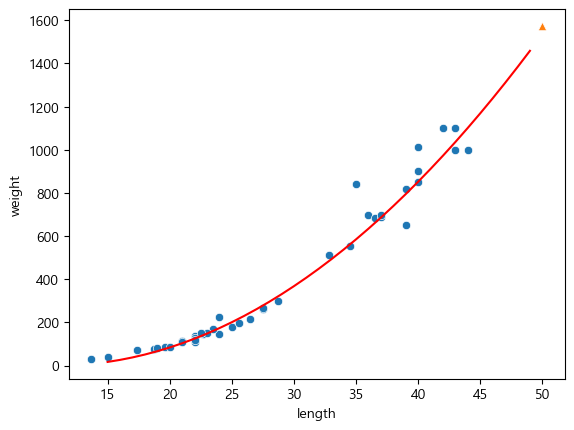

In [28]:
plt.xlabel('length')
plt.ylabel('weight')

sns.scatterplot(x=X_train, y=Y_train)          # 훈련셋 산점도
sns.scatterplot(x=[50], y=[1574], marker='^')  # 50cm 농어 데이터 

# 2차 방정식 그래프
point=np.arange(15, 50)      # 구간별 직선을 그리기 위해서 15 ~ 49 정수 배열
w=1.0 * point**2 - 21.6 * point + 116.05     # 기울기*point**2 - 기울기*point+졀편
w                            

sns.lineplot(x=point, y=w, c='red')  
plt.show()

## 사이킷런의 변환기

In [57]:
from sklearn.preprocessing import PolynomialFeatures       # 폴리노미얼 피처스 

In [47]:
data=[[2, 3]]
poly=PolynomialFeatures()   # 기본값  degree=2
poly.fit_transform(data)    # 1:절편, 2:데이터, 3:데이터, 4:2^2, 6:2*3(특성끼리 곱), 9:3^2   

array([[1., 2., 3., 4., 6., 9.]])

In [49]:
data=[[2, 3]]
poly=PolynomialFeatures(include_bias=False)   # 절편 사용하지 않겠다. 
poly.fit_transform(data) 

array([[2., 3., 4., 6., 9.]])

In [53]:
data=[[2, 3]]
poly=PolynomialFeatures(include_bias=False, degree=5)  
poly.fit_transform(data)     # X1=2, X2=3, X1^2=4, X1X2=6, X1^2=9
                             # X1^3=8, X1^2xX2=12, X1X2^2=18, X2^3=27
# poly.get_feature_names_out()

array([[  2.,   3.,   4.,   6.,   9.,   8.,  12.,  18.,  27.,  16.,  24.,
         36.,  54.,  81.,  32.,  48.,  72., 108., 162., 243.]])

## 실습문제 - 농어 무게 예측 

In [33]:
# 농어 무게 예측 : 농어 (길이, 높이, 두께, 무게)
perch_df=pd.read_csv('./Data/perch_full.csv')
perch_df.head()

,length,height,width,weight
0,8.4,2.11,1.41,5.9
1,13.7,3.53,2.00,32.0
2,15.0,3.82,2.43,40.0
3,16.2,4.59,2.63,51.5
4,17.4,4.59,2.94,70.0


In [35]:
perch_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 56 entries, 0 to 55
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   length  56 non-null     float64
 1   height  56 non-null     float64
 2   width   56 non-null     float64
 3   weight  56 non-null     float64
dtypes: float64(4)
memory usage: 1.9 KB


In [37]:
perch_df.describe().T

,count,mean,std,min,25%,50%,75%,max
length,56.0,27.892857,9.021668,8.40,21.825,25.300,36.625,44.00
height,56.0,7.862143,2.878343,2.11,5.690,6.920,10.850,12.80
width,56.0,4.745536,1.775006,1.41,3.520,4.155,6.450,8.14
weight,56.0,382.239286,347.617717,5.90,120.000,207.500,692.500,1100.00


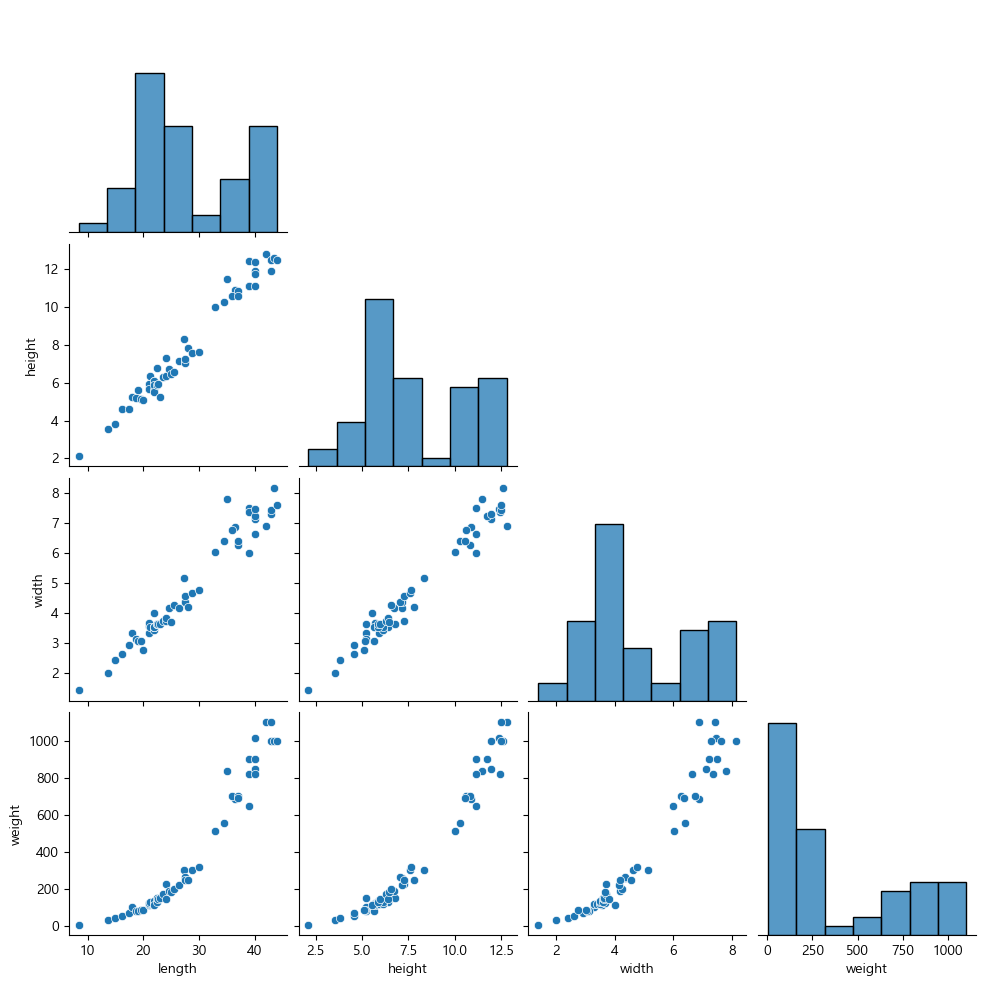

In [39]:
# sns.scatterplot(data=perch_df, x='length', y='weight', label='length')
# sns.scatterplot(data=perch_df, x='width', y='weight', label='width')
# sns.scatterplot(data=perch_df, x='height', y='weight',  label='height')

# plt.xlabel('length/width/height')
# plt.ylabel('weight')
# plt.show()

sns.pairplot(data=perch_df, corner=True)
plt.show()

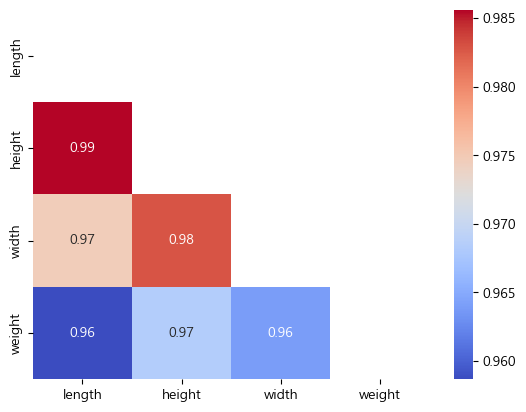

In [35]:
sns.heatmap(perch_df.corr(), 
            annot=True, 
            cmap='coolwarm', 
            mask=np.triu(np.ones_like(perch_df.corr(), dtype=bool)))
plt.show()

In [37]:
X=perch_df[['length', 'height', 'width']]
Y=perch_df['weight']
X.shape, Y.shape

((56, 3), (56,))

In [39]:
X_train, X_test, Y_train, Y_test=train_test_split(X, Y, random_state=42)

poly=PolynomialFeatures(include_bias=False)    # default degree=2,  degree=5 해보기
poly.fit(X_train)

X_train_poly=poly.transform(X_train)
print(X_train_poly.shape)  
print(X_train_poly[:3])
print(poly.get_feature_names_out())

X_test_poly=poly.transform(X_test)
print(X_test_poly.shape)

(42, 9)
[[ 19.6      5.14     3.04   384.16   100.744   59.584   26.4196  15.6256
    9.2416]
 [ 22.       5.88     3.52   484.     129.36    77.44    34.5744  20.6976
   12.3904]
 [ 18.7      5.2      3.12   349.69    97.24    58.344   27.04    16.224
    9.7344]]
['length' 'height' 'width' 'length^2' 'length height' 'length width'
 'height^2' 'height width' 'width^2']
(14, 9)


In [41]:
scaler=StandardScaler()
scaler.fit(X_train_poly)

X_train_scaled=scaler.transform(X_train_poly)
X_test_scaled=scaler.transform(X_test_poly)

In [43]:
lr=LinearRegression()
lr.fit(X_train_scaled, Y_train)

print("학습:", lr.score(X_train_scaled, Y_train))
print("일반화:", lr.score(X_test_scaled, Y_test))

학습: 0.9903183436982124
일반화: 0.9714559911594133


In [45]:
print(lr.coef_, lr.intercept_)  

[  303.79797864  -254.82826832  -321.53684302 -1191.04767776
  1407.14218929   908.51794857  1374.63985081 -3567.76517863
  1696.94993949] 400.833333333334


In [68]:
# from statsmodels.stats.outliers_influence import variance_inflation_factor

# col=perch_df.drop(['weight'], axis=1)
# vif=pd.DataFrame()
# vif['변수명']=col.columns
# vif["다중 공선상(VIF)"]=[variance_inflation_factor(col.values, i) for i in range(len(col.columns))]
# vif

# X=perch_df[['height']]
# Y=perch_df['weight']
# X.shape, Y.shape

# X_train, X_test, Y_train, Y_test=train_test_split(X, Y, random_state=42)

# poly=PolynomialFeatures(include_bias=False)   
# poly.fit(X_train)

# X_train_poly=poly.transform(X_train)
# print(X_train_poly.shape)  
# print(X_train_poly[:3])
# print(poly.get_feature_names_out())

# X_test_poly=poly.transform(X_test)
# print(X_test_poly.shape)

# lr=LinearRegression()
# lr.fit(X_train_poly, Y_train)

# print("학습:", lr.score(X_train_poly, Y_train))     # 98
# print("일반화:", lr.score(X_test_poly, Y_test))     # 97 
# print(lr.coef_, lr.intercept_)  

In [61]:
# lr.predict([[50**2, 50]])

# new_df=pd.DataFrame(data=[[8.4, 2.11, 1.41]], columns=['length', 'height', 'width'])
# new_df_poly=poly.transform(new_df)
# new_df_scaled=scaler.transform(new_df_poly)
# pred=lr.predict(new_df_scaled)
# pred

## Ridg - L2규제
* 데이터 준비 >> 설명(특성)과 목표 변수 분리 >> 훈련 세트와 테스트 세트 분할
* 데이터 스케일링 >> Lasso 회귀 모델 훈련 >> 예측 및 성능 평가

In [86]:
# 릿지회귀 : (가중치) ^ 2 / L2규제
ridge=Ridge()              # default 1.0
ridge.fit(X_train_scaled, Y_train)

print("학습:", ridge.score(X_train_scaled, Y_train))
print("일반화:", ridge.score(X_test_scaled, Y_test))
print("회귀계수:", ridge.coef_, ridge.intercept_)  

학습: 0.9857915060511934
일반화: 0.9835057194929057
회귀계수: [-14.8457435  -13.99600726 -32.35418375  74.19692179  78.1435485
  60.69735429  82.15125951  64.36969483  49.56283536] 400.83333333333326


### Hypter Parameter

In [89]:
# alpha_list=[0.001, 0.01, 1.0, 1, 10, 100]    # 로그 스케일(10배씩 곱해지는 형태) / 10^-3=0.001

# for i in alpha_list:
#   ridge=Ridge(alpha=i)                       # default alpha=1.0
#   ridge.fit(X_train_scaled, Y_train)

#   print(i, "------------------------------------")
#   print(ridge.score(X_train_scaled, Y_train))
#   print(ridge.score(X_test_scaled, Y_test))
#   print(ridge.coef_, ridge.intercept_)  
#   print()

In [91]:
alpha_list=[0.001, 0.01, 0.1, 1, 10, 100]    # 로그 스케일(10배씩 곱해지는 형태)

results=[]
for i in alpha_list:
    ridge=Ridge(alpha=i)                     # default alpha=1.0
    ridge.fit(X_train_scaled, Y_train)

    train_score=ridge.score(X_train_scaled, Y_train)
    test_score=ridge.score(X_test_scaled, Y_test)

    results.append({
        "alpha": i,
        "train_score": train_score,
        "test_score": test_score
    })

df=pd.DataFrame(results)
df.sort_values(by=['train_score', 'test_score'], ascending=[False, False])

,alpha,train_score,test_score
0,0.001,0.989753,0.983262
1,0.010,0.989364,0.983938
2,0.100,0.988935,0.985656
3,1.000,0.985792,0.983506
4,10.000,0.977677,0.966089
5,100.000,0.932545,0.939913


In [93]:
ridge=Ridge(alpha=0.1)
ridge.fit(X_train_scaled, Y_train)

print(ridge.score(X_train_scaled, Y_train))
print(ridge.score(X_test_scaled, Y_test))

0.9889354346720892
0.9856564835209134


## Lasso - L1 규제

In [96]:
# 라쏘 : |가중치| / L1규제
lasso=Lasso()        # default alpha=1.0
lasso.fit(X_train_scaled, Y_train)

print(lasso.score(X_train_scaled, Y_train))
print(lasso.score(X_test_scaled, Y_test))
print(lasso.coef_, lasso.intercept_)  

0.986591255464559
0.9846056618190412
[ -0.         -75.17036118  -0.          47.65512744 146.84457339
   9.1970512  157.66441571   0.          62.6831403 ] 400.8333333333333


In [98]:
# Hype paramemeter
alpha_list=[0.001, 0.01, 1.0, 1, 10, 100]    # 로그 스케일(10배씩 곱해지는 형태)
results=[]

for i in alpha_list:
  # lasso=Lasso(alpha=i)                      # 값이 너무 작아져서 경고 
  lasso=Lasso(alpha=i, tol=0.01)              # 수렴 기준을 완화하여 조기 종료  기본값 : 1e-4
  lasso.fit(X_train_scaled, Y_train)

  train_score=lasso.score(X_train_scaled, Y_train)
  test_score=lasso.score(X_test_scaled, Y_test)

  results.append({
    "alpha": i,
    "train_score": train_score,
    "test_score": test_score
  })

df=pd.DataFrame(results)
df.sort_values(by=['train_score', 'test_score'], ascending=[False, False])

,alpha,train_score,test_score
1,0.010,0.984579,0.983114
0,0.001,0.984574,0.983113
2,1.000,0.983520,0.978677
3,1.000,0.983520,0.978677
4,10.000,0.982661,0.977117
5,100.000,0.902329,0.906169


In [100]:
lasso=Lasso(alpha=10)
lasso.fit(X_train_scaled, Y_train)

print(lasso.score(X_train_scaled, Y_train))
print(lasso.score(X_test_scaled, Y_test))

0.9827254657543516
0.9778291802263332


## ElasticNet - L1 + L2

- l1_ratio=1이면 Lasso (완전한 L1 정규화)
- l1_ratio=0이면 Ridge (완전한 L2 정규화)

In [68]:
elastic_net=ElasticNet()        # default alpha=1.0
elastic_net.fit(X_train_scaled, Y_train)

print(elastic_net.score(X_train_scaled, Y_train))
print(elastic_net.score(X_test_scaled, Y_test))

0.9742674602032548
0.9649273414103385


In [70]:
alpha_list=[0.001, 0.01, 1.0, 1, 10, 100] 
results=[]

for i in alpha_list:
    elastic_net=ElasticNet(alpha=i, tol=0.01)   
    elastic_net.fit(X_train_scaled, Y_train)
        
    train_score=elastic_net.score(X_train_scaled, Y_train)
    test_score=elastic_net.score(X_test_scaled, Y_test)

    results.append({
        "alpha": i,
        "train_score": train_score,
        "test_score": test_score
    })

df=pd.DataFrame(results)
df.sort_values(by=["train_score", "test_score"], ascending=[False, False])

# 반복 계산 중 계수 변화량 또는 목적 함수 변화량이 tol보다 작아지면 수렴했다고 판단, 멈춤

,alpha,train_score,test_score
0,0.001,0.984438,0.982696
1,0.010,0.983974,0.981050
2,1.000,0.974468,0.964977
3,1.000,0.974468,0.964977
4,10.000,0.842862,0.858245
5,100.000,0.235297,0.207994


# Logistic Regression
* 이진 분류 문제에 사용되는 머신러닝 
* 이름은 회귀라는 단어가 들어가지만 실제로는 분류를 수행하는 알고리즘
* 선형 방정식 학습 z = a * (Weight) +  b * (Length) +  c * (Diagonal) + d * (Height) + e * (Width) + f
* 시그모이드 함수를 사용하여 확률로 변환 0~1 

In [83]:
import numpy as np
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt
import matplotlib as mpl  
mpl.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus']=False

from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

from sklearn.linear_model import LogisticRegression  
from scipy.special import expit, softmax    # 엣스핏

In [85]:
# 데이터 불러오기
fish=pd.read_csv('./Data/fish_data.csv')
fish.shape     # (159, 6)
fish.head()

# Species(종) / Weight(무게) / Length(길이) / Diagonal(대각선, 다이애거널) / Height(높이) / Width(폭)

,Species,Weight,Length,Diagonal,Height,Width
0,Bream,242.0,25.4,30.0,11.5200,4.0200
1,Bream,290.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,26.5,31.1,12.3778,4.6961
3,Bream,363.0,29.0,33.5,12.7300,4.4555
4,Bream,430.0,29.0,34.0,12.4440,5.1340


In [87]:
fish['Species'].value_counts()

# Perch: 쏘가리 / Bream: 빙어 / Roach: 달새기 / Pike: 강꼬치어 
# Smelt: 농어 / Parkki: 파르키 / Whitefish: 백어

Species
Perch        56
Bream        35
Roach        20
Pike         17
Smelt        14
Parkki       11
Whitefish     6
Name: count, dtype: int64

## 이진분류 - Sigmoid 
### 데이터 전처리

In [90]:
# 도미 & 빙어 데이터 가져오기   스피시즈(종)
bream_smelt_fish=fish[(fish['Species'] == 'Bream') | (fish['Species'] == 'Smelt')]
bream_smelt_fish.shape    # (49, 6)

(49, 6)

In [92]:
bream_smelt_fish['Species'].value_counts()

Species
Bream    35
Smelt    14
Name: count, dtype: int64

In [94]:
bream_smelt_fish.head(2)

,Species,Weight,Length,Diagonal,Height,Width
0,Bream,242.0,25.4,30.0,11.52,4.0200
1,Bream,290.0,26.3,31.2,12.48,4.3056


In [96]:
bream_smelt_fish.info()                         # 데이터 타입 및 결측치 확인

<class 'pandas.DataFrame'>
Index: 49 entries, 0 to 158
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Species   49 non-null     str    
 1   Weight    49 non-null     float64
 2   Length    49 non-null     float64
 3   Diagonal  49 non-null     float64
 4   Height    49 non-null     float64
 5   Width     49 non-null     float64
dtypes: float64(5), str(1)
memory usage: 2.9 KB


In [98]:
bream_smelt_fish.describe().T.astype(int)          #  연속형 : 기술 통계량, 이상치 확인

,count,mean,std,min,25%,50%,75%,max
Weight,49,444,328,6,19,500,700,1000
Length,49,27,10,9,14,31,34,41
Diagonal,49,31,12,10,15,36,39,46
Height,49,11,6,1,2,14,15,18
Width,49,4,1,1,1,5,5,6


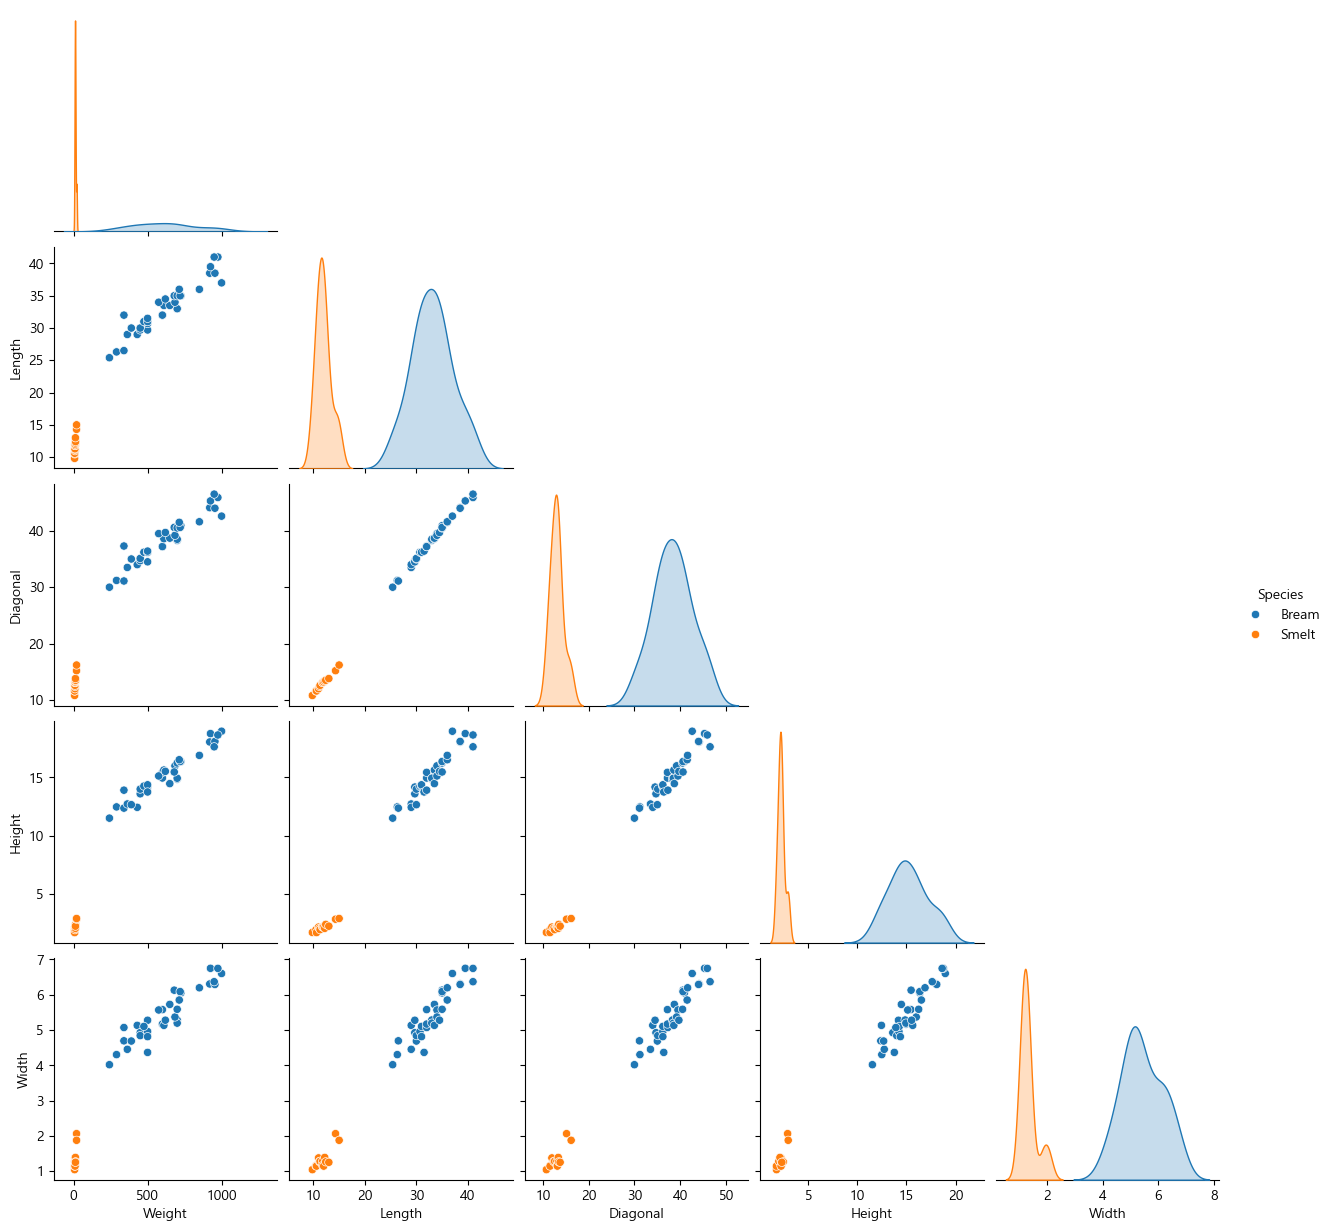

In [100]:
sns.pairplot(data=bream_smelt_fish, corner=True, hue='Species')
plt.show()

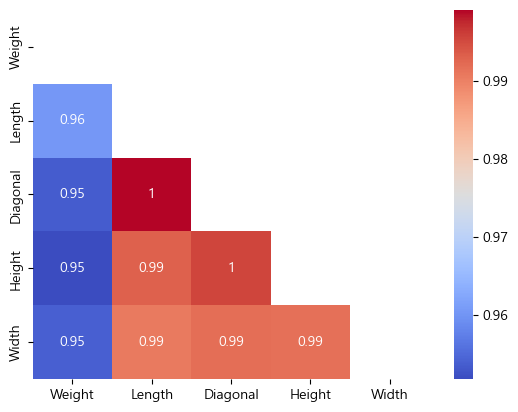

In [103]:
sns.heatmap(bream_smelt_fish.corr(numeric_only=True), 
            annot=True, 
            cmap='coolwarm', 
            mask=np.triu(np.ones_like(bream_smelt_fish.corr(numeric_only=True), dtype=bool)))
plt.show()

In [106]:
# X=bream_smelt_fish[['Length']]
# Y=bream_smelt_fish['Species']

In [49]:
# 설명 및 목표 변수 설정
X=bream_smelt_fish.iloc[:, 1:6]     # bream_smelt_fish.drop(df.columns[0], axis=1)
Y=bream_smelt_fish['Species']
X.shape, Y.shape

((49, 5), (49,))

### 훈련 & 평가

In [56]:
# 학습 및 테스트 데이터 셋
X_train, X_test, Y_train, Y_test=train_test_split(X, Y, random_state=42)

# 데이터 스케일 - 표준화
scaler=StandardScaler()
scaler.fit(X_train)

X_train_scaled=scaler.transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [58]:
# 로지스틱 회귀 모델 학습
lr=LogisticRegression()
lr.fit(X_train_scaled, Y_train)

print("학습:",  lr.score(X_train_scaled, Y_train))
print("일반화:", lr.score(X_test_scaled, Y_test))

학습: 1.0
일반화: 1.0


In [60]:
# 평가 지표 : 정확도, 정밀도, 재현율, f1스코어
Y_test_pred=lr.predict(X_test_scaled)
print(classification_report(Y_test, Y_test_pred))

              precision    recall  f1-score   support

       Bream       1.00      1.00      1.00        10
       Smelt       1.00      1.00      1.00         3

    accuracy                           1.00        13
   macro avg       1.00      1.00      1.00        13
weighted avg       1.00      1.00      1.00        13



In [62]:
# 회귀 계수 확인 
print("기울기:", lr.coef_)
print("절편:", lr.intercept_)
print("클래스:", lr.classes_)

# 기울기 특성 5개, 절편 1개 

기울기: [[-0.57717269 -0.79233938 -0.82533982 -0.86579233 -0.82205625]]
절편: [-2.38186126]
클래스: ['Bream' 'Smelt']


In [69]:
# z값 출력 
d=lr.decision_function(X_test_scaled[:5])     # 결정값 
expit(d)                                      # 시그모이드 함수

array([0.01840178, 0.95009904, 0.90701723, 0.95104955, 0.00684335])

In [66]:
Y_test_pred[:5]

array(['Bream', 'Smelt', 'Smelt', 'Smelt', 'Bream'], dtype=object)

## 다중분류 - Softmax 

### 데이터 전처리

In [132]:
# 데이터 불러오기
fish=pd.read_csv('./Data/fish_data.csv')
fish.shape     # (159, 6)
fish.head()

# Species(종) / Weight(무게) / Length(길이) / Diagonal(대각선) / Height(높이) / Width(폭)

,Species,Weight,Length,Diagonal,Height,Width
0,Bream,242.0,25.4,30.0,11.5200,4.0200
1,Bream,290.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,26.5,31.1,12.3778,4.6961
3,Bream,363.0,29.0,33.5,12.7300,4.4555
4,Bream,430.0,29.0,34.0,12.4440,5.1340


In [134]:
fish.info()

<class 'pandas.DataFrame'>
RangeIndex: 159 entries, 0 to 158
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Species   159 non-null    str    
 1   Weight    159 non-null    float64
 2   Length    159 non-null    float64
 3   Diagonal  159 non-null    float64
 4   Height    159 non-null    float64
 5   Width     159 non-null    float64
dtypes: float64(5), str(1)
memory usage: 8.4 KB


In [136]:
fish.describe().T.astype(int)

,count,mean,std,min,25%,50%,75%,max
Weight,159,398,357,0,120,273,650,1650
Length,159,28,10,8,21,27,35,63
Diagonal,159,31,11,8,23,29,39,68
Height,159,8,4,1,5,7,12,18
Width,159,4,1,1,3,4,5,8


In [142]:
fish.describe(include='str').T

,count,unique,top,freq
Species,159,7,Perch,56


In [144]:
fish['Species'].value_counts()

# Perch: 쏘가리 / Bream: 빙어 / Roach: 달새기 / Pike: 강꼬치어 
# Smelt: 농어 / Parkki: 파르키 / Whitefish: 백어

Species
Perch        56
Bream        35
Roach        20
Pike         17
Smelt        14
Parkki       11
Whitefish     6
Name: count, dtype: int64

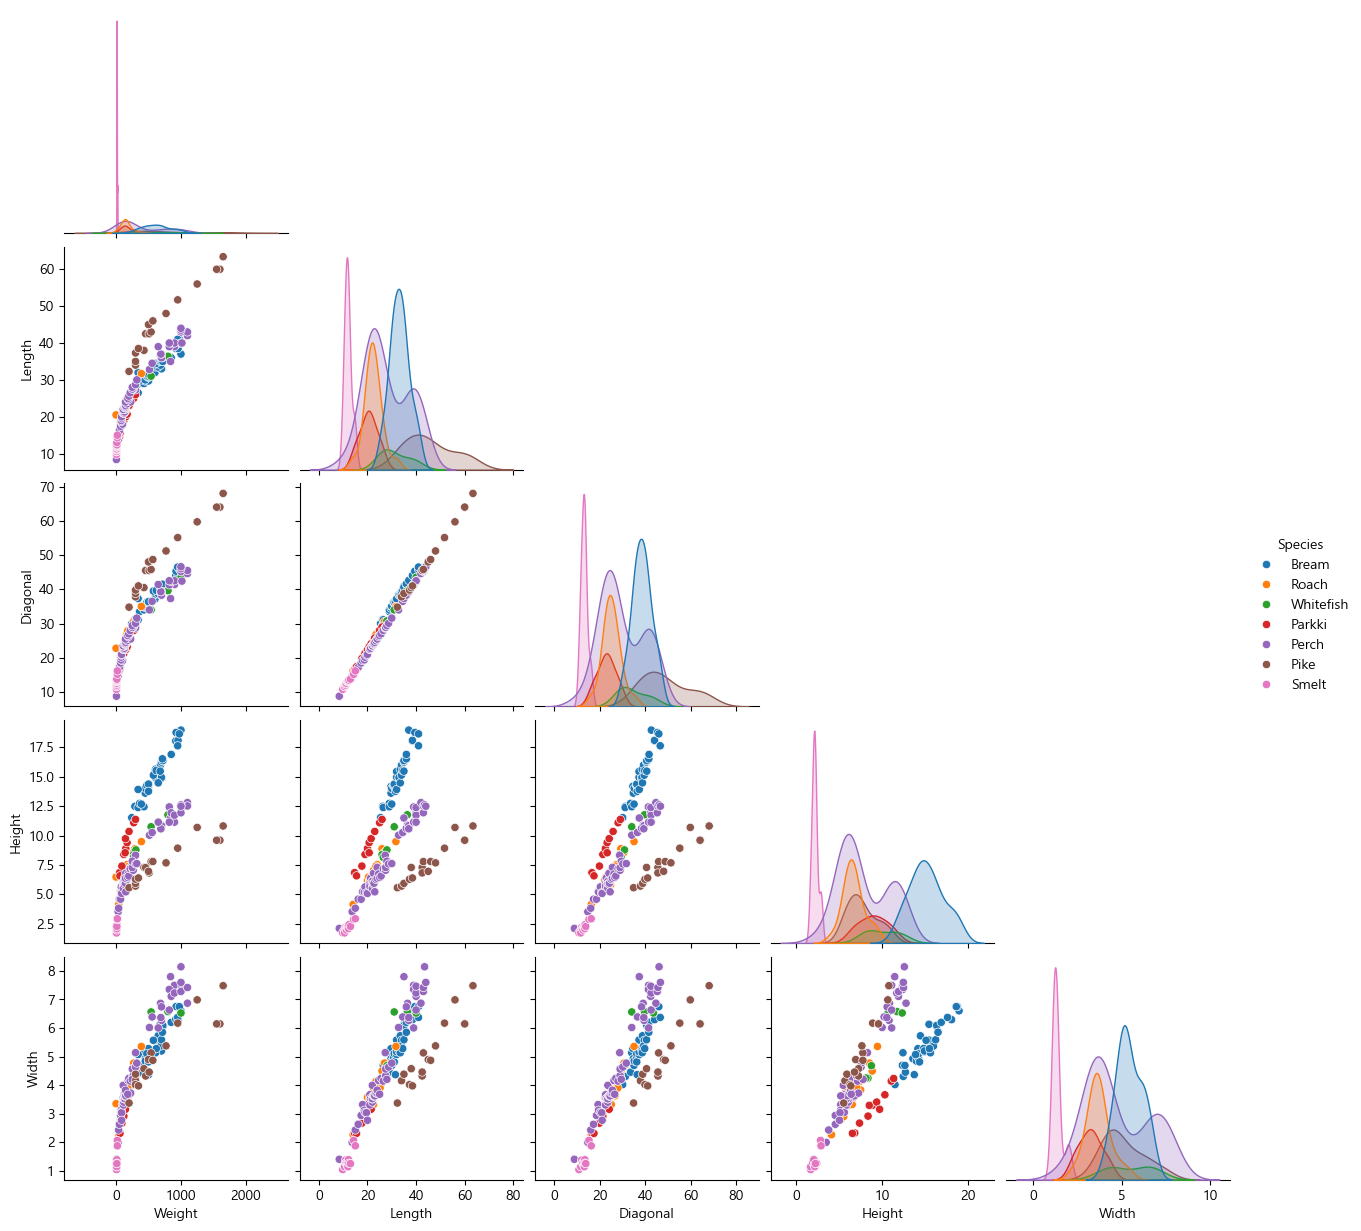

In [150]:
sns.pairplot(data=fish, corner=True, hue='Species')
plt.show()

### 훈련 및 평가

In [18]:
# 설명 및 목표 변수 설정
X=fish.iloc[:, 1:6]
Y=fish['Species']
X.shape, Y.shape

((159, 5), (159,))

In [20]:
# 학습 및 테스트 데이터 셋
X_train, X_test, Y_train, Y_test=train_test_split(X, Y, random_state=42)

# 데이터 스케일 - 표준화
scaler=StandardScaler()
scaler.fit(X_train)

X_train_scaled=scaler.transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [26]:
# 로지스틱 회귀 모델 학습
lr=LogisticRegression()
lr.fit(X_train_scaled, Y_train)

print(lr.score(X_train_scaled, Y_train))
print(lr.score(X_test_scaled, Y_test))

0.8067226890756303
0.85


In [30]:
# penalty(페널티)='L2' : L1, L2, elasticnet
# C: 규제 강도 (alpha 반대로 작을수록 규제가 커진다)  >> 역수, 작은값 단순화

lr=LogisticRegression(C=20)
lr.fit(X_train_scaled, Y_train)

print("학습:",  lr.score(X_train_scaled, Y_train))
print("일반화:", lr.score(X_test_scaled, Y_test))

학습: 0.9327731092436975
일반화: 0.925


In [142]:
Y_test_pred=lr.predict(X_test_scaled[:5])
Y_test_pred

array(['Perch', 'Smelt', 'Pike', 'Roach', 'Perch'], dtype=object)

In [144]:
# 데이터 너무 적으면 안나옴 - 정밀도 ERROR
# Y_test_pred=lr.predict(X_test_scaled)
# print(classification_report(Y_test, Y_test_pred))

In [146]:
# 회귀 계수 확인
print("가중치:", lr.coef_)     
print("절편:", lr.intercept_)  

가중치: [[-1.50605455 -1.03747913  2.60919713  7.69422738 -1.18603341]
 [ 0.19200047 -1.99988811 -3.79617725  6.50312639 -2.00022755]
 [ 3.55793539  6.36988929 -8.52233732 -5.75397234  3.79233438]
 [-0.11453308  3.61060121  3.94464503 -3.62243903 -1.7598168 ]
 [-1.40843716 -6.0924219   5.28629633 -0.86696568  1.84518454]
 [-1.33419956  1.48153393  1.38217548 -5.6602348  -4.39228962]
 [ 0.61328847 -2.33223528 -0.9037994   1.70625808  3.70084846]]
절편: [-0.10345044 -0.27281216  3.24444852 -0.1756507   2.64960026 -6.72042855
  1.37829307]


In [150]:
print("클래스 값:", lr.classes_)

클래스 값: ['Bream' 'Parkki' 'Perch' 'Pike' 'Roach' 'Smelt' 'Whitefish']


In [148]:
# z값 출력
d=lr.decision_function(X_test_scaled[:5])    # 결정값 
d

# 소프트 맥스 함수 
softmax(d, axis=1).round(3)                 # 각행의 소프트맥스 계산

array([[0.   , 0.014, 0.842, 0.   , 0.135, 0.007, 0.003],
       [0.   , 0.003, 0.044, 0.   , 0.007, 0.946, 0.   ],
       [0.   , 0.   , 0.034, 0.934, 0.015, 0.016, 0.   ],
       [0.011, 0.034, 0.305, 0.006, 0.567, 0.   , 0.076],
       [0.   , 0.   , 0.904, 0.002, 0.089, 0.002, 0.001]])

## 실습문제 - 염색 불량 예측 

### 데이터 전처리

In [58]:
dye=pd.read_csv('./Data/염색공정_5000_회귀.csv', encoding='cp949')
dye.shape            

(5000, 11)

In [60]:
dye.head(2)

,단위중량(kg),투입중량(kg),염색길이(m),투입중량/길이,투입중량/액량,공정진행시간(%),진행온도,포속1,포속3,포속4,염색색차 DE
0,324.0,38.8,96.0,0.404167,0.0388,23.41,133.2,74,72,20,0.291673
1,324.0,38.8,96.0,0.404167,0.0388,21.88,127.1,73,146,18,0.291673


In [62]:
def sub(val):
    if val > 3:           
        return "불량"
    elif val > 2:         
        return "이상"
    elif val <= 2:         
        return "정상"

dye['품질']=dye['염색색차 DE'].apply(sub)

In [64]:
dye['품질'].value_counts(normalize=True)

품질
정상    0.7276
불량    0.1518
이상    0.1206
Name: proportion, dtype: float64

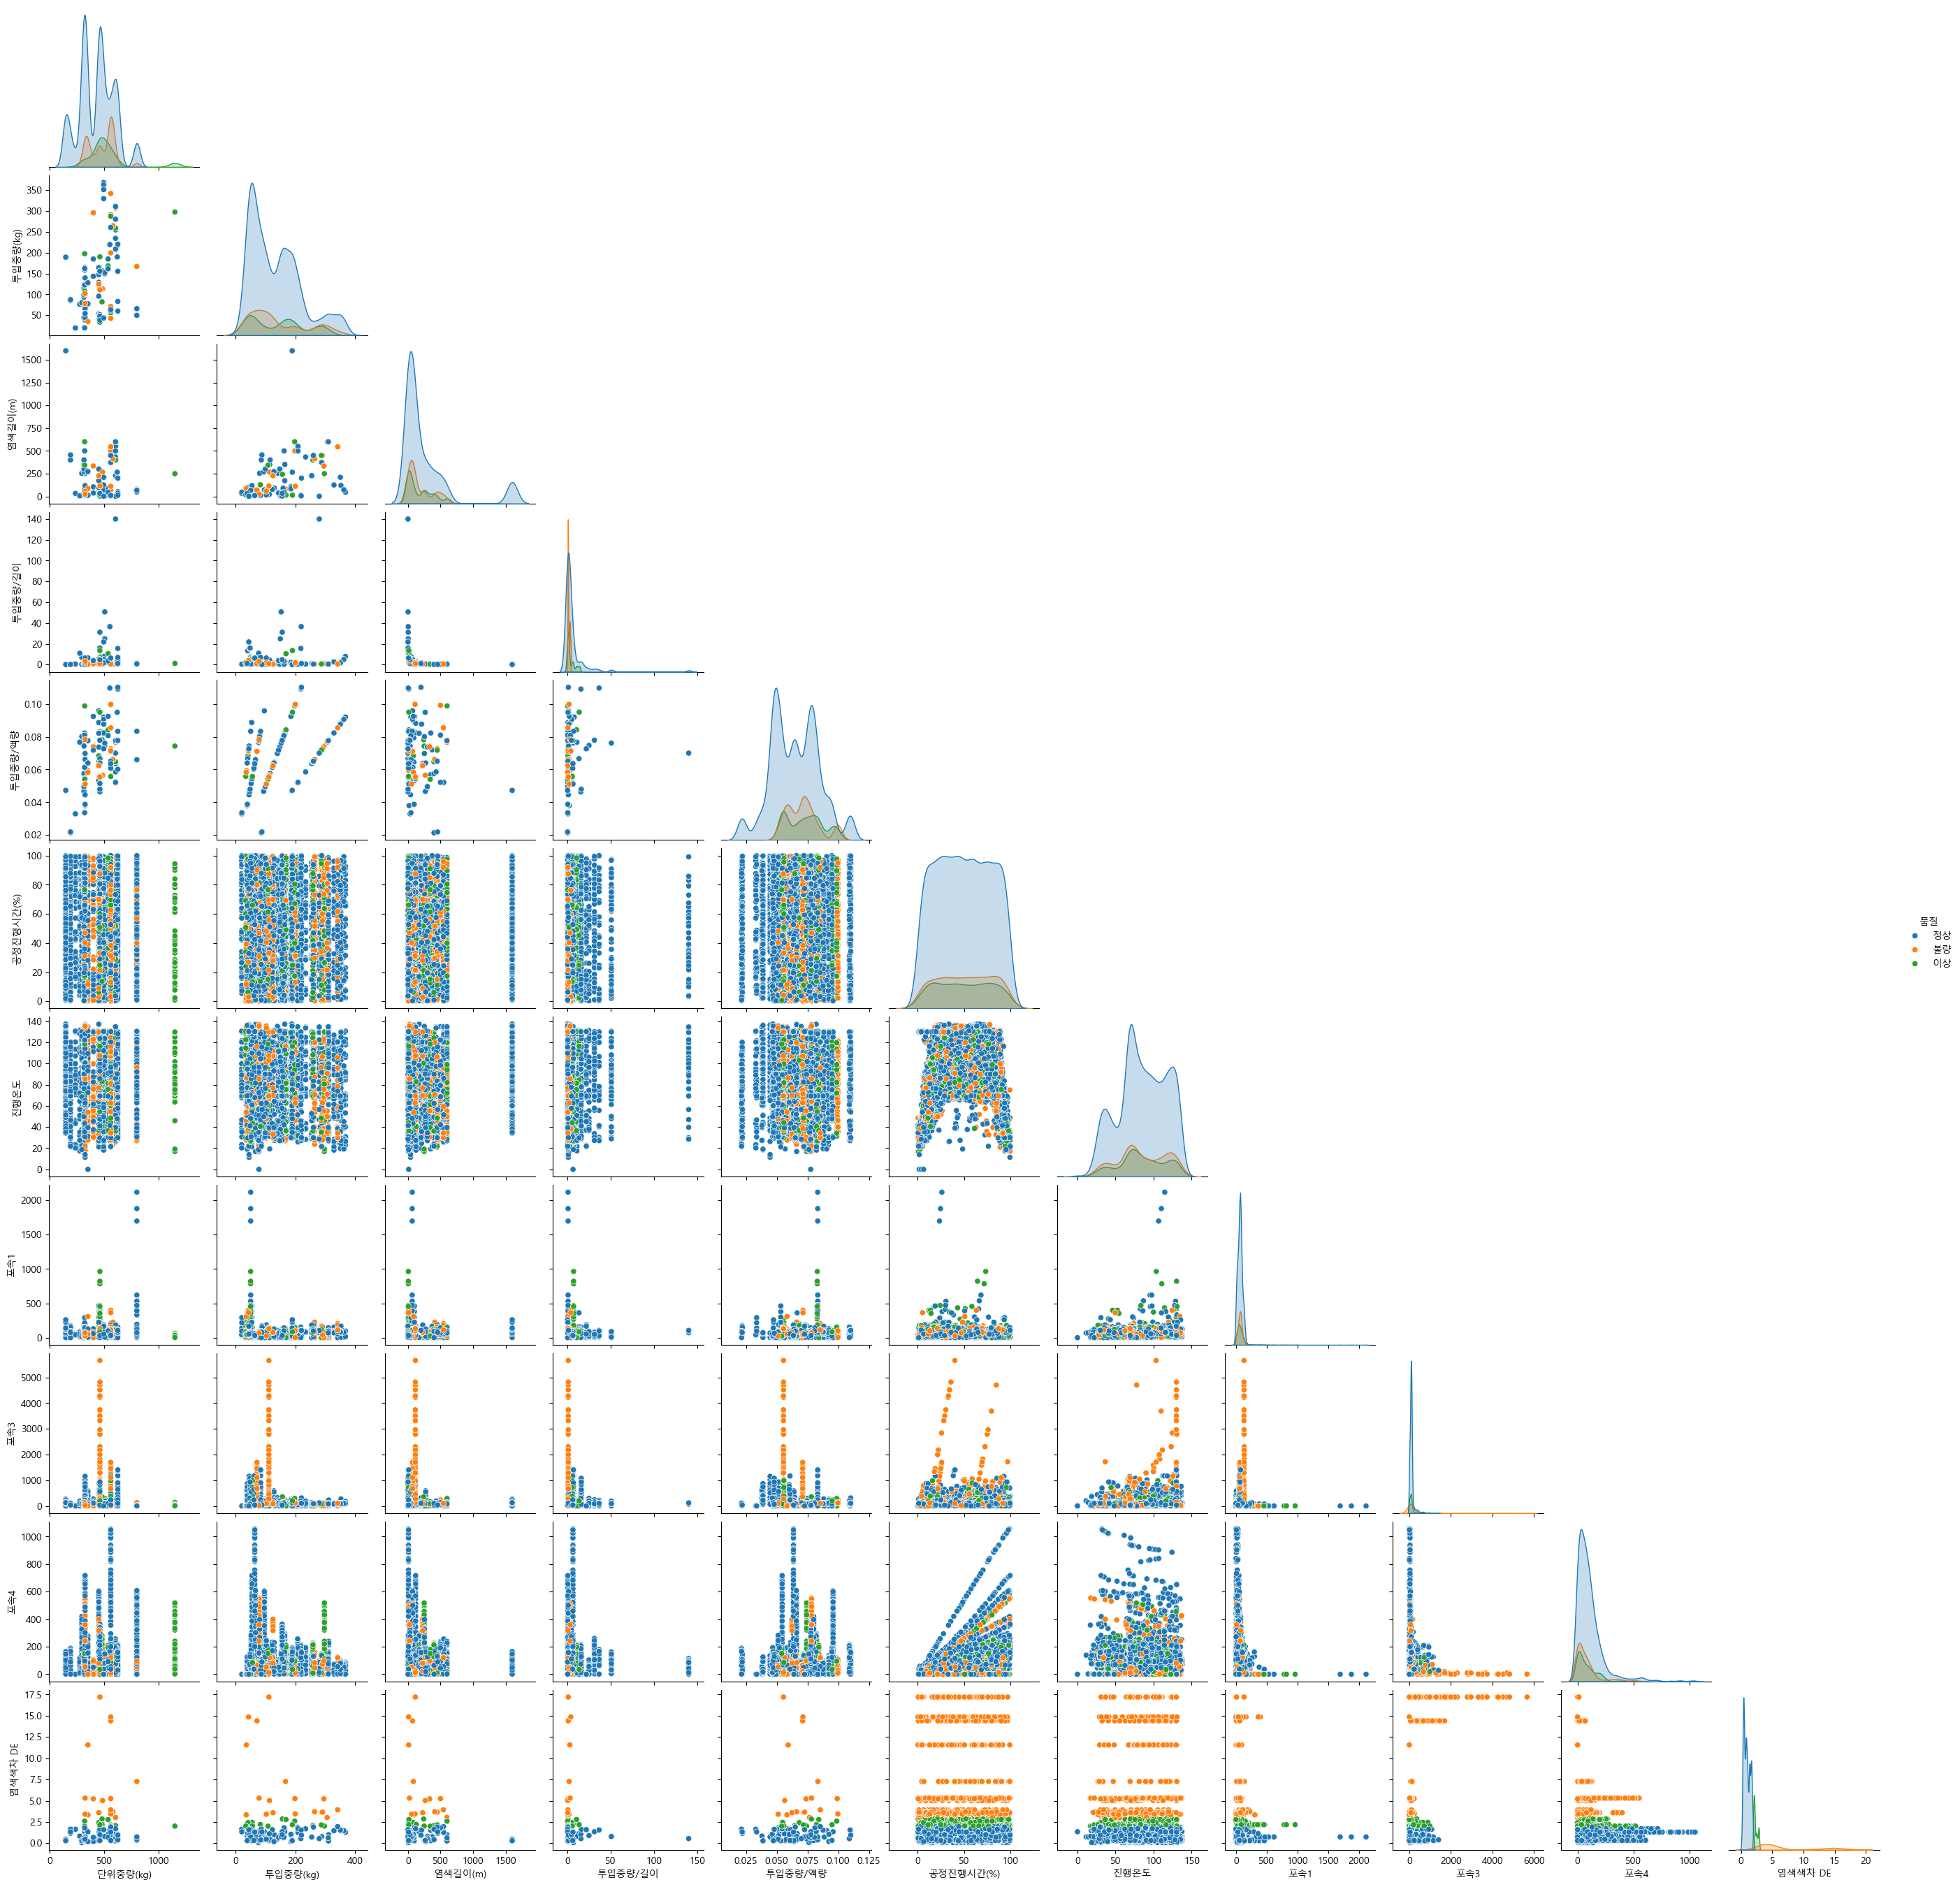

In [21]:
sns.pairplot(data=dye, corner=True, hue='품질')
plt.show()

### 학습 및 평가

In [66]:
dye.columns

Index(['단위중량(kg)', '투입중량(kg)', '염색길이(m)', '투입중량/길이', '투입중량/액량', '공정진행시간(%)',
       '진행온도', '포속1', '포속3', '포속4', '염색색차 DE', '품질'],
      dtype='str')

In [68]:
X=dye.iloc[:, :-2]
Y=dye.iloc[:, -1]

In [70]:
X_train, X_test, Y_train, Y_test=train_test_split(X, Y, stratify=Y, random_state=1234)
scaler=StandardScaler()
scaler.fit(X_train)

X_train_scaled=scaler.transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [72]:
lr=LogisticRegression(class_weight='balanced')             # 불량률 10% 이하 적극검토,  불량률 10~20%  둘 다 비교
lr.fit(X_train_scaled, Y_train)

print("학습:",  lr.score(X_train_scaled, Y_train))
print("일반화:", lr.score(X_test_scaled, Y_test))

학습: 0.5184
일반화: 0.5088


In [74]:
# 평가 지표 : 정확도, 정밀도, 재현율, f1
Y_test_pred=lr.predict(X_test_scaled)
print(classification_report(Y_test, Y_test_pred))

              precision    recall  f1-score   support

          불량       0.22      0.55      0.31       190
          이상       0.28      0.44      0.34       151
          정상       0.87      0.51      0.64       909

    accuracy                           0.51      1250
   macro avg       0.46      0.50      0.43      1250
weighted avg       0.70      0.51      0.56      1250



In [76]:
# 회귀 계수 확인
print("가중치:", lr.coef_)
print("절편:", lr.intercept_)
print("클래스:", lr.classes_)    

가중치: [[-0.09892114  0.213873   -0.92119761 -3.0241119   0.29902281  0.07573512
  -0.04260303  0.00871004  0.24177807 -0.13777537]
 [ 0.38322607 -0.31415768  0.40718877  1.07409296  0.21242785  0.09307225
  -0.01611875  0.05077261 -0.20256689 -0.18543205]
 [-0.28430493  0.10028468  0.51400884  1.95001894 -0.51145065 -0.16880736
   0.05872178 -0.05948265 -0.03921118  0.32320742]]
절편: [-0.70455197  0.19697467  0.50757731]
클래스: ['불량' '이상' '정상']


In [78]:
d=lr.decision_function(X_test_scaled[:5])
expit(d)

array([[8.86954152e-14, 9.99975806e-01, 9.99999996e-01],
       [6.95274746e-01, 5.56865471e-01, 2.58582940e-01],
       [6.96121763e-01, 4.08711517e-01, 3.87079996e-01],
       [4.97963272e-01, 6.70466817e-01, 3.31335673e-01],
       [5.37510668e-01, 4.79839781e-01, 4.82596909e-01]])

In [80]:
Y_test_pred[:5]

array(['정상', '불량', '불량', '이상', '불량'], dtype=object)

In [246]:
# --- End Of ----------------------------------------